# Step 2 — Face & facial-landmark detection with MTCNN

Faces are the basic data blocks for every later step of the deepfake detector, so this notebook
builds the face-extraction stage:

1. **Detect a face and its eye locations in a single image** (the core deliverable).
2. **Loop a video through its frames** and detect faces + landmarks in every frame.
3. Pull, from the detector, each face's **bounding box** (top-left `x, y` + `width, height`) and the
   **left / right eye** coordinates — exactly the inputs the future `crop_and_align()` needs.
4. **Save the extracted faces to disk** so we never have to repeat the (slow) detection step.

**Detector:** MTCNN (via `facenet-pytorch`). MTCNN is more accurate than dlib and returns 5 facial
landmarks per face — both eyes, the nose, and the two mouth corners — which is ideal for eye-based
face alignment.

## Imports

⚠️ **macOS note:** PyTorch and OpenCV each bundle their own OpenMP runtime, which segfaults when both
load. Setting `KMP_DUPLICATE_LIB_OK` **before** importing them is the standard workaround — keep this as
the very first cell.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  
os.environ.setdefault("OMP_NUM_THREADS", "1")

import cv2
import glob
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from facenet_pytorch import MTCNN

/Users/blake/opt/anaconda3/envs/deepfake-detect/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Locate the data folders

Walk up from the working directory until we find `Data/`, so the paths work no matter where the
notebook is launched from.

In [2]:
root = Path.cwd()
while not (root / "Data").exists() and root != root.parent:
    root = root.parent

REAL_DIR = root / "Data" / "VidTIMIT"                              # original videos
FAKE_DIR = root / "Data" / "DeepfakeTIMIT" / "higher_quality"      # deepfake videos
print("Project root:", root)

Project root: /Users/blake/AI Projects/Deepfake-Detection


## Create the MTCNN detector

`keep_all=True` returns **every** face in the image (not just the most confident one). We run on CPU;
`device="cuda"` would use a GPU if available.

In [3]:
detector = MTCNN(keep_all=True, device="cpu")
print("MTCNN detector ready")

MTCNN detector ready


## 1. Detect a face and eye locations in a single image  ⭐ (the deliverable)

`MTCNN.detect(..., landmarks=True)` returns three arrays:

- **boxes** — one `[x1, y1, x2, y2]` per face,
- **probs** — detection confidence per face,
- **landmarks** — 5 points per face, in the order `[left_eye, right_eye, nose, mouth_left, mouth_right]`.

The helper below repackages that into the format the next milestone's `crop_and_align()` expects:
each face as its **bounding box `(x, y, w, h)`** plus **left/right eye** coordinates.

> MTCNN expects an **RGB** image. OpenCV loads frames as **BGR**, so we convert first.

In [4]:
def detect_faces(image_rgb):
    """Detect faces in an RGB image.

    Returns a list with one dict per detected face:
        box        : (x, y, w, h)  -> top-left corner + width + height
        left_eye   : (x, y)
        right_eye  : (x, y)
        nose       : (x, y)
        confidence : float
    Returns [] when no face is found.
    """
    boxes, probs, landmarks = detector.detect(image_rgb, landmarks=True)
    faces = []
    if boxes is None:
        return faces
    for box, prob, lm in zip(boxes, probs, landmarks):
        x1, y1, x2, y2 = (float(v) for v in box)
        faces.append({
            "box":        (x1, y1, x2 - x1, y2 - y1),      # (x, y, w, h)
            "left_eye":   tuple(float(v) for v in lm[0]),
            "right_eye":  tuple(float(v) for v in lm[1]),
            "nose":       tuple(float(v) for v in lm[2]),
            "confidence": float(prob),
        })
    return faces

In [5]:
# Grab one frame from a real video and detect the face + eyes in it.
sample_video = str(REAL_DIR / "fadg0" / "sa1.avi")
cap = cv2.VideoCapture(sample_video)
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ok, frame_bgr = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
faces = detect_faces(frame_rgb)

print(f"Detected {len(faces)} face(s)")
for i, f in enumerate(faces):
    x, y, w, h = (round(v, 1) for v in f["box"])
    print(f"  face {i}: confidence={f['confidence']:.3f}")
    print(f"           box (x,y,w,h) = ({x}, {y}, {w}, {h})")
    print(f"           left_eye  = {tuple(round(v,1) for v in f['left_eye'])}")
    print(f"           right_eye = {tuple(round(v,1) for v in f['right_eye'])}")

Detected 1 face(s)
  face 0: confidence=0.999
           box (x,y,w,h) = (183.8, 83.0, 131.8, 170.5)
           left_eye  = (217.6, 148.2)
           right_eye = (278.2, 143.9)


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


### Visualise the detection — bounding box + eye locations

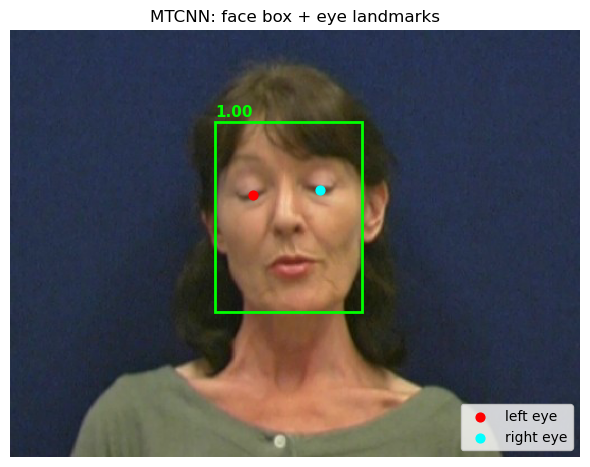

In [6]:
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(frame_rgb)
for f in faces:
    x, y, w, h = f["box"]
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor="lime", linewidth=2))
    lx, ly = f["left_eye"]
    rx, ry = f["right_eye"]
    ax.scatter([lx], [ly], c="red",    s=40, marker="o", label="left eye")
    ax.scatter([rx], [ry], c="cyan",   s=40, marker="o", label="right eye")
    ax.text(x, y - 6, f"{f['confidence']:.2f}", color="lime", fontsize=11, weight="bold")
ax.legend(loc="lower right"); ax.set_title("MTCNN: face box + eye landmarks"); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Loop a video through its frames and detect faces in each one

Detection is run on **every** frame. We record how many faces were found per frame — a good sanity
check that the detector tracks the face throughout the clip.

In [7]:
cap = cv2.VideoCapture(sample_video)
per_frame_counts = []
frame_idx = 0
while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break
    faces = detect_faces(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    per_frame_counts.append(len(faces))
    frame_idx += 1
cap.release()

total = sum(per_frame_counts)
print(f"Processed {frame_idx} frames")
print(f"Frames with exactly 1 face: {per_frame_counts.count(1)} / {frame_idx}")
print(f"Total faces detected: {total}")

Processed 119 frames
Frames with exactly 1 face: 119 / 119
Total faces detected: 119


## 3. `crop_and_align()` — placeholder for the next milestone

The next milestone implements the real `crop_and_align()`, which will **rotate** each face so the eyes
lie on a horizontal line, then crop and scale to a fixed size. Its signature is fixed now so the rest of
the pipeline can be built against it:

```python
crop_and_align(image, box, left_eye, right_eye, size) -> face_image
```

For now we use a **simple interim version** that just crops the bounding box and resizes — enough to
produce and save face images. The eye-based rotation/alignment is deliberately left for the next step
(the eye coordinates are already passed in, ready to be used).

In [8]:
def crop_and_align(image, box, left_eye, right_eye, size=160):
    """PLACEHOLDER (full eye-alignment comes in the next milestone).

    Args:
        image      : RGB image (H, W, 3)
        box        : (x, y, w, h) face bounding box
        left_eye   : (x, y) left-eye coordinate   -- unused for now, used next milestone
        right_eye  : (x, y) right-eye coordinate  -- unused for now, used next milestone
        size       : output square size in pixels
    Returns:
        (size, size, 3) RGB face crop.
    """
    x, y, w, h = (int(round(v)) for v in box)
    H, W = image.shape[:2]
    x0, y0 = max(0, x), max(0, y)
    x1, y1 = min(W, x + w), min(H, y + h)
    crop = image[y0:y1, x0:x1]
    return cv2.resize(crop, (size, size))

## 4. Extract and save the faces to disk

Face detection is slow, so we save each cropped face as a JPEG. Later steps load these directly instead
of re-running MTCNN on every video.

In [9]:
def extract_and_save_faces(video_path, out_dir, size=160):
    """Detect, crop/align and save every face of a video. Returns #faces saved."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    saved, idx = 0, 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        image_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        for j, f in enumerate(detect_faces(image_rgb)):
            face = crop_and_align(image_rgb, f["box"], f["left_eye"], f["right_eye"], size)
            face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)      # back to BGR for imwrite
            cv2.imwrite(str(out_dir / f"frame{idx:04d}_face{j}.jpg"), face_bgr)
            saved += 1
        idx += 1
    cap.release()
    return saved

faces_root = root / "Data" / "faces" / "fadg0_sa1_real"
n_saved = extract_and_save_faces(sample_video, faces_root)
print(f"Saved {n_saved} face crops to {faces_root}")

Saved 119 face crops to /Users/blake/AI Projects/Deepfake-Detection/Data/faces/fadg0_sa1_real


### Preview a few of the saved faces

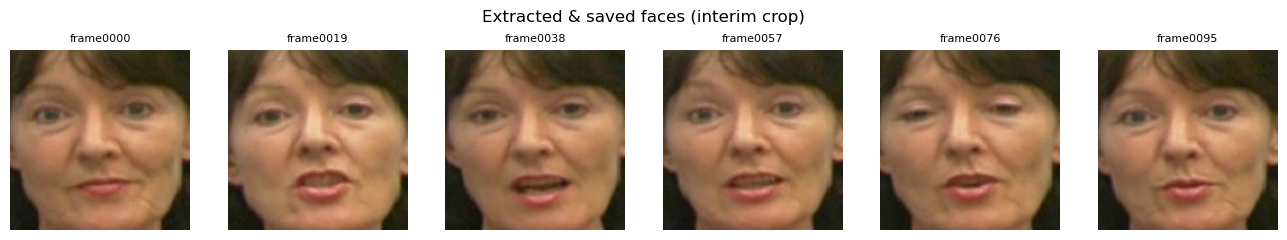

In [10]:
saved_files = sorted(glob.glob(str(faces_root / "*.jpg")))
picks = saved_files[::max(1, len(saved_files) // 6)][:6]
fig, axes = plt.subplots(1, len(picks), figsize=(2.2 * len(picks), 2.4))
for ax, fp in zip(np.atleast_1d(axes), picks):
    ax.imshow(cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB))
    ax.set_title(Path(fp).stem.split("_")[0], fontsize=8); ax.axis("off")
plt.suptitle("Extracted & saved faces (interim crop)"); plt.tight_layout(); plt.show()

## Summary

- **MTCNN** detects faces and returns 5 landmarks; we extract each face's **bounding box `(x, y, w, h)`**
  and **left/right eye** coordinates.
- We looped a video frame-by-frame and detected the face in every frame (~1 face/frame throughout).
- Detected faces are **cropped and saved to `Data/faces/`** so detection isn't repeated later.
- The real eye-based **`crop_and_align()`** is stubbed with the correct signature and will be completed in
  the next milestone — the eye coordinates it needs are already being passed through.

The exact same pipeline runs on the deepfake videos under `Data/DeepfakeTIMIT/higher_quality/` — just point
`sample_video` at a fake clip.